# Lab 1: Quantum States & Measurement using Qiskit

**Topics:** Hilbert space, tensor products, measurement, sampling, and entanglement  
**Tool:** Qiskit SDK + Python

In this lab, you will represent quantum states as vectors, compute probabilities from amplitudes, simulate repeated measurements, combine qubits using tensor products, and create a Bell state.

By the end of the lab, you should be able to:

1. Represent one-qubit and two-qubit states as complex vectors.
2. Check whether a state is normalized.
3. Use inner products to measure overlap between states.
4. Construct multi-qubit states using tensor products.
5. Compute measurement probabilities from a statevector.
6. Explain why sampling produces fluctuating counts.
7. Compare separable and entangled two-qubit states.

## 0. Environment setup

Run the following cell only if the required packages are missing in your notebook environment. If everything is already installed, the cell will simply report that the required packages are available.

In [1]:
# Run this cell only if the required packages are missing.
# It avoids upgrading core packages unless installation is needed.

import importlib.util
import subprocess
import sys

required_modules = ["qiskit", "ipywidgets", "matplotlib", "numpy"]
missing = [m for m in required_modules if importlib.util.find_spec(m) is None]

if missing:
    print("Missing packages:", missing)
    print("Installing required packages...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qiskit[visualization]",
        "ipywidgets",
        "matplotlib",
        "numpy",
        "pylatexenc"
    ])
    print("Installation complete. Restart the kernel if widgets do not appear.")
else:
    print("Required packages are already available.")

Missing packages: ['qiskit']
Installing required packages...
Installation complete. Restart the kernel if widgets do not appear.


## 1. Imports and helper functions

The helper functions below keep the rest of the notebook readable. They print states, check normalization, plot probability distributions, and display circuits.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace
from qiskit.visualization import plot_histogram

np.set_printoptions(precision=4, suppress=True)

In [3]:
def complex_format(z, digits=4):
    """Format a complex number compactly for printed statevectors."""
    z = complex(z)
    real = 0.0 if abs(z.real) < 10**(-digits) else z.real
    imag = 0.0 if abs(z.imag) < 10**(-digits) else z.imag
    if imag == 0:
        return f"{real:.{digits}f}"
    if real == 0:
        return f"{imag:.{digits}f}j"
    sign = "+" if imag >= 0 else "-"
    return f"{real:.{digits}f} {sign} {abs(imag):.{digits}f}j"


def print_vector(vector, labels=None, title=None, digits=4):
    """Print amplitudes with basis labels."""
    vector = np.asarray(vector, dtype=complex)
    if labels is None:
        labels = [str(i) for i in range(len(vector))]
    if title:
        display(Markdown(f"**{title}**"))
    for label, amp in zip(labels, vector):
        print(f"|{label}> : {complex_format(amp, digits)}")


def norm_squared(vector):
    """Return the sum of squared magnitudes of a vector."""
    vector = np.asarray(vector, dtype=complex)
    return float(np.sum(np.abs(vector) ** 2))


def is_normalized(vector, tol=1e-10):
    """Check whether a vector satisfies the quantum-state normalization rule."""
    return abs(norm_squared(vector) - 1.0) < tol


def normalize(vector):
    """Normalize a nonzero vector so that its squared norm becomes 1."""
    vector = np.asarray(vector, dtype=complex)
    nrm = np.sqrt(norm_squared(vector))
    if nrm == 0:
        raise ValueError("The zero vector cannot be normalized into a quantum state.")
    return vector / nrm


def probability_dict_from_vector(vector, labels=None, digits=4):
    """Compute measurement probabilities from squared magnitudes."""
    vector = np.asarray(vector, dtype=complex)
    if labels is None:
        labels = [str(i) for i in range(len(vector))]
    probs = np.abs(vector) ** 2
    return {label: round(float(prob), digits) for label, prob in zip(labels, probs) if prob > 10**(-digits)}


def plot_probabilities(prob_dict, title="Probability distribution"):
    """Plot a probability dictionary using Qiskit's histogram visualizer."""
    fig = plot_histogram(prob_dict, title=title)
    display(fig)
    plt.close(fig)


def display_circuit(qc, title=None):
    """Display a Qiskit circuit. Falls back to text if graphical rendering is unavailable."""
    if title:
        display(Markdown(f"**{title}**"))
    try:
        display(qc.draw(output="mpl"))
        plt.close()
    except Exception:
        print(qc.draw(output="text"))


def print_statevector(sv, title=None, digits=4):
    """Print the nonzero amplitudes of a Qiskit Statevector."""
    if title:
        display(Markdown(f"**{title}**"))
    for label, amp in sv.to_dict().items():
        if abs(amp) > 10**(-digits):
            print(f"|{label}> : {complex_format(amp, digits)}")


def sample_counts(sv, shots=1000):
    """Sample a Statevector in the computational basis."""
    return dict(sv.sample_counts(shots=shots))


def density_purity(dm):
    """Return Tr(rho^2). Pure states have purity 1; mixed states have purity less than 1."""
    data = np.asarray(dm.data, dtype=complex)
    return float(np.real_if_close(np.trace(data @ data)))

## 2. Qiskit bitstring convention

When Qiskit prints a two-qubit bitstring such as `01`, the **rightmost bit corresponds to qubit 0** in the default circuit convention.

For example, applying `X` to `q[0]` in a two-qubit circuit changes the displayed state from `00` to `01`.

This is only a labeling convention. The physics is unchanged, but being aware of it prevents confusion when reading printed statevectors and measurement counts.

**Circuit that flips q[0]**

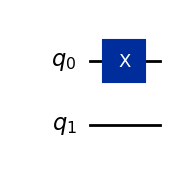

**Statevector after X on q[0]**

|01> : 1.0000


In [4]:
qc_order = QuantumCircuit(2)
qc_order.x(0)  # flip q[0]

display_circuit(qc_order, "Circuit that flips q[0]")
sv_order = Statevector.from_instruction(qc_order)
print_statevector(sv_order, "Statevector after X on q[0]")

## Experiment 1: Basis states in Hilbert space

A one-qubit computational basis has two states:

$$
|0\rangle = \begin{bmatrix}1 \\ 0\end{bmatrix},
\qquad
|1\rangle = \begin{bmatrix}0 \\ 1\end{bmatrix}.
$$

A general one-qubit state is

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle,
\qquad \alpha,\beta \in \mathbb{C}.
$$

**Task:** create the basis vectors and inspect their amplitudes.

In [5]:
zero = np.array([1, 0], dtype=complex)
one = np.array([0, 1], dtype=complex)

print_vector(zero, labels=["0", "1"], title="Vector representation of |0>")
print()
print_vector(one, labels=["0", "1"], title="Vector representation of |1>")

**Vector representation of |0>**

|0> : 1.0000
|1> : 0.0000



**Vector representation of |1>**

|0> : 0.0000
|1> : 1.0000


In [6]:
# Qiskit's Statevector object represents the same mathematical idea.
sv_zero = Statevector(zero)
sv_one = Statevector(one)

print_statevector(sv_zero, "Qiskit Statevector for |0>")
print()
print_statevector(sv_one, "Qiskit Statevector for |1>")

**Qiskit Statevector for |0>**

|0> : 1.0000



**Qiskit Statevector for |1>**

|1> : 1.0000


**Takeaway:** A qubit is represented as a vector in a two-dimensional complex Hilbert space.

## Experiment 2: Valid and invalid quantum states

For a one-qubit state

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle,
$$

the normalization rule is

$$
|\alpha|^2 + |\beta|^2 = 1.
$$

**Task:** test valid and invalid vectors.

In [7]:
plus = (zero + one) / np.sqrt(2)
invalid = np.array([1, 1], dtype=complex)

for name, vec in [("|+> = (|0> + |1>)/sqrt(2)", plus), ("[1, 1]^T", invalid)]:
    print(name)
    print_vector(vec, labels=["0", "1"])
    print("squared norm:", norm_squared(vec))
    print("is normalized?", is_normalized(vec))
    print("probabilities:", probability_dict_from_vector(vec, labels=["0", "1"]))
    print("-" * 50)

|+> = (|0> + |1>)/sqrt(2)
|0> : 0.7071
|1> : 0.7071
squared norm: 0.9999999999999998
is normalized? True
probabilities: {'0': 0.5, '1': 0.5}
--------------------------------------------------
[1, 1]^T
|0> : 1.0000
|1> : 1.0000
squared norm: 2.0
is normalized? False
probabilities: {'0': 1.0, '1': 1.0}
--------------------------------------------------


In [8]:
# Normalize the invalid vector and check again.
normalized_invalid = normalize(invalid)

print_vector(normalized_invalid, labels=["0", "1"], title="Normalized version of [1, 1]^T")
print("squared norm:", norm_squared(normalized_invalid))
print("is normalized?", is_normalized(normalized_invalid))
print("probabilities:", probability_dict_from_vector(normalized_invalid, labels=["0", "1"]))

**Normalized version of [1, 1]^T**

|0> : 0.7071
|1> : 0.7071
squared norm: 0.9999999999999998
is normalized? True
probabilities: {'0': 0.5, '1': 0.5}


**Takeaway:** Not every vector is a valid quantum state. A valid state must have total probability equal to 1.

## Experiment 3: Inner product, orthogonality, and overlap

The inner product between two complex vectors uses conjugation:

$$
\langle a|b\rangle = \sum_i a_i^* b_i.
$$

The quantity

$$
|\langle a|b\rangle|^2
$$

measures overlap between two quantum states.

In [9]:
minus = (zero - one) / np.sqrt(2)

inner_0_1 = np.vdot(zero, one)       # vdot conjugates the first input
inner_0_plus = np.vdot(zero, plus)
inner_plus_minus = np.vdot(plus, minus)

print("<0|1> =", inner_0_1)
print("|<0|1>|^2 =", abs(inner_0_1) ** 2)
print()
print("<0|+> =", inner_0_plus)
print("|<0|+>|^2 =", abs(inner_0_plus) ** 2)
print()
print("<+|-> =", inner_plus_minus)
print("|<+|->|^2 =", abs(inner_plus_minus) ** 2)

<0|1> = 0j
|<0|1>|^2 = 0.0

<0|+> = (0.7071067811865475+0j)
|<0|+>|^2 = 0.4999999999999999

<+|-> = 0j
|<+|->|^2 = 0.0


**Takeaway:** Orthogonal states have zero overlap. The states $|0\rangle$ and $|+\rangle$ are not orthogonal; measuring $|+\rangle$ in the computational basis can produce outcome 0 with probability 0.5.

## Experiment 4: Tensor products and two-qubit states

Individual qubits are combined using tensor products:

$$
|00\rangle = |0\rangle \otimes |0\rangle,
\qquad
|01\rangle = |0\rangle \otimes |1\rangle.
$$

For two qubits, the computational basis is

$$
|00\rangle, |01\rangle, |10\rangle, |11\rangle.
$$

**Task:** construct two-qubit basis states manually.

In [10]:
labels_2q = ["00", "01", "10", "11"]

ket_00 = np.kron(zero, zero)
ket_01 = np.kron(zero, one)
ket_10 = np.kron(one, zero)
ket_11 = np.kron(one, one)

for label, vec in [("|00>", ket_00), ("|01>", ket_01), ("|10>", ket_10), ("|11>", ket_11)]:
    print_vector(vec, labels=labels_2q, title=label)
    print()

**|00>**

|00> : 1.0000
|01> : 0.0000
|10> : 0.0000
|11> : 0.0000



**|01>**

|00> : 0.0000
|01> : 1.0000
|10> : 0.0000
|11> : 0.0000



**|10>**

|00> : 0.0000
|01> : 0.0000
|10> : 1.0000
|11> : 0.0000



**|11>**

|00> : 0.0000
|01> : 0.0000
|10> : 0.0000
|11> : 1.0000



**Takeaway:** Two qubits require four amplitudes. In general, $n$ qubits require $2^n$ amplitudes.

## Experiment 5: Measurement probabilities from a statevector

If

$$
|\psi\rangle = \sum_i \alpha_i |i\rangle,
$$

then the probability of measuring outcome $i$ is

$$
P(i)=|\alpha_i|^2.
$$

**Task:** compute and plot the probabilities for $|+\rangle$.

**Statevector for |+>**

|0> : 0.7071
|1> : 0.7071
probabilities: {np.str_('0'): np.float64(0.5), np.str_('1'): np.float64(0.5)}


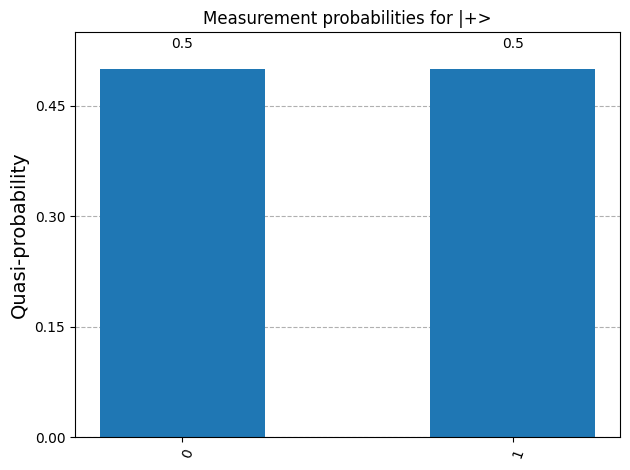

In [11]:
sv_plus = Statevector(plus)

print_statevector(sv_plus, "Statevector for |+>")
print("probabilities:", sv_plus.probabilities_dict(decimals=4))

plot_probabilities(sv_plus.probabilities_dict(decimals=4), title="Measurement probabilities for |+>")

**Takeaway:** Measurement probabilities come from squared amplitudes. For $|+\rangle$, both outcomes have probability 0.5.

## Interactive playground: change the state and the number of shots

A one-qubit pure state can be written as

$$
|\psi(\theta,\phi)\rangle = \cos(\theta/2)|0\rangle + e^{i\phi}\sin(\theta/2)|1\rangle.
$$

Use the sliders to change the state and observe how the probabilities and sampled counts change.

In [12]:
def state_from_angles(theta, phi):
    """Create a one-qubit Statevector from Bloch-sphere angles theta and phi."""
    alpha = np.cos(theta / 2)
    beta = np.exp(1j * phi) * np.sin(theta / 2)
    return Statevector([alpha, beta])


def angle_playground(theta=np.pi/2, phi=0.0, shots=500):
    sv = state_from_angles(theta, phi)
    probs = sv.probabilities_dict(decimals=4)
    counts = sample_counts(sv, shots=int(shots))

    print_statevector(sv, "State amplitudes")
    print("Ideal probabilities:", probs)
    print(f"Sampled counts for {int(shots)} shots:", counts)
    plot_probabilities(probs, title="Ideal probabilities")
    plot_probabilities(counts, title=f"Sampled counts ({int(shots)} shots)")

try:
    import ipywidgets as widgets
    widgets.interact(
        angle_playground,
        theta=widgets.FloatSlider(value=np.pi/2, min=0, max=np.pi, step=0.05, description="theta"),
        phi=widgets.FloatSlider(value=0.0, min=0, max=2*np.pi, step=0.05, description="phi"),
        shots=widgets.IntSlider(value=500, min=10, max=5000, step=10, description="shots"),
    )
except Exception:
    print("Interactive widgets are not available in this environment.")
    print("You can still call angle_playground(theta, phi, shots) manually.")
    print("Example: angle_playground(np.pi/2, 0, 500)")

interactive(children=(FloatSlider(value=1.5707963267948966, description='theta', max=3.141592653589793, step=0…

**What to try:**

- Set $\theta=0$. Which outcome has probability 1?
- Set $\theta=\pi$. Which outcome has probability 1?
- Set $\theta=\pi/2$. What are the probabilities?
- Change $\phi$ while keeping $\theta=\pi/2$. Do the computational-basis probabilities change?

## Experiment 6: Sampling and shot noise

A probability distribution describes many repeated measurements. A single measurement gives one classical outcome.

**Task:** sample $|+\rangle$ using different shot counts.

   10 shots -> {np.str_('0'): np.int64(5), np.str_('1'): np.int64(5)}


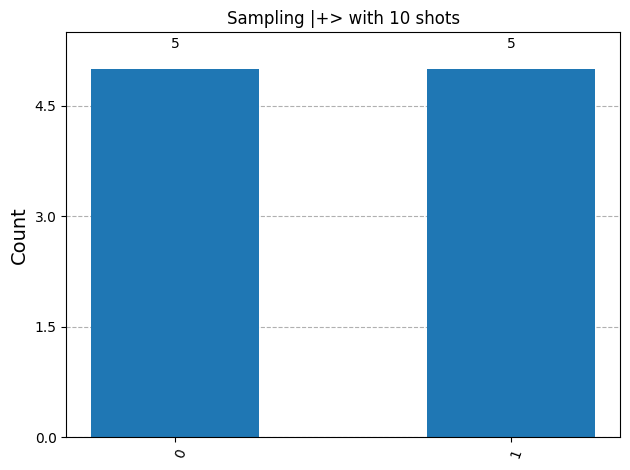

  100 shots -> {np.str_('0'): np.int64(38), np.str_('1'): np.int64(62)}


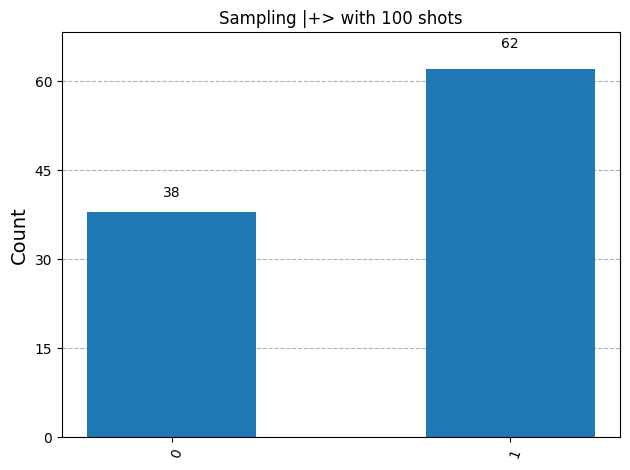

 1000 shots -> {np.str_('0'): np.int64(511), np.str_('1'): np.int64(489)}


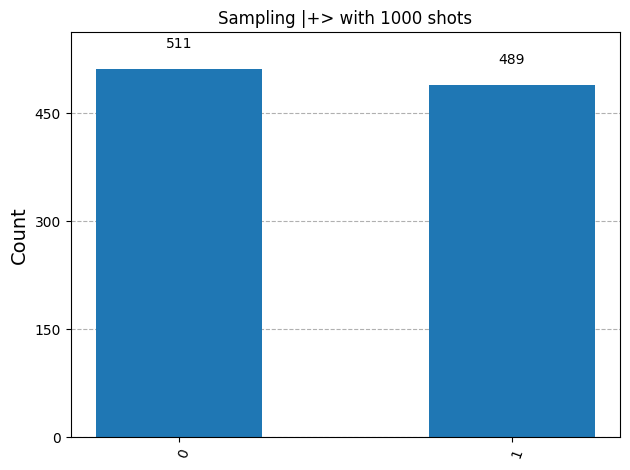

10000 shots -> {np.str_('0'): np.int64(4935), np.str_('1'): np.int64(5065)}


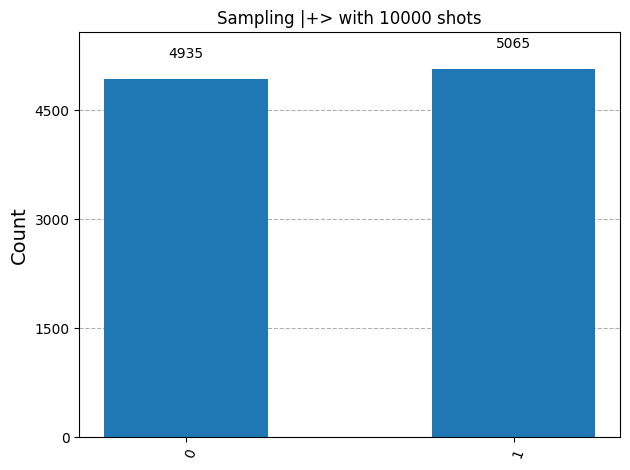

In [13]:
shot_values = [10, 100, 1000, 10000]

for shots in shot_values:
    counts = sample_counts(sv_plus, shots=shots)
    print(f"{shots:5d} shots -> {counts}")
    plot_probabilities(counts, title=f"Sampling |+> with {shots} shots")

**Takeaway:** With few shots, the observed counts can look uneven. With many shots, the measured frequencies tend to approach the ideal probabilities.

## Experiment 7: Separable two-qubit states

A two-qubit state is separable if it can be written as

$$
|\psi\rangle_{AB} = |a\rangle \otimes |b\rangle.
$$

Example:

$$
|+\rangle \otimes |0\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle).
$$

**Task:** construct the state manually and using a circuit.

In [14]:
plus_tensor_zero = np.kron(plus, zero)

print_vector(plus_tensor_zero, labels=labels_2q, title="Manual construction of |+> ⊗ |0>")
print("probabilities:", probability_dict_from_vector(plus_tensor_zero, labels=labels_2q))

**Manual construction of |+> ⊗ |0>**

|00> : 0.7071
|01> : 0.0000
|10> : 0.7071
|11> : 0.0000
probabilities: {'00': 0.5, '10': 0.5}


**Circuit for a separable two-qubit state**

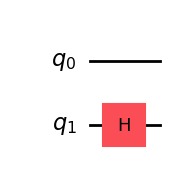

**Statevector from the circuit**

|00> : 0.7071
|10> : 0.7071
probabilities: {np.str_('00'): np.float64(0.5), np.str_('10'): np.float64(0.5)}


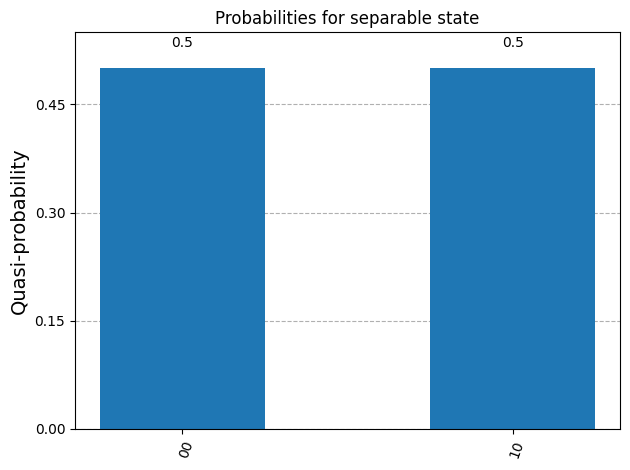

In [15]:
qc_sep = QuantumCircuit(2)
qc_sep.h(1)  # prepares the left-side mathematical qubit in |+>

display_circuit(qc_sep, "Circuit for a separable two-qubit state")
sv_sep = Statevector.from_instruction(qc_sep)
print_statevector(sv_sep, "Statevector from the circuit")
print("probabilities:", sv_sep.probabilities_dict(decimals=4))
plot_probabilities(sv_sep.probabilities_dict(decimals=4), title="Probabilities for separable state")

**Takeaway:** A separable state can contain superposition, but the total state can still be written as a tensor product of individual qubit states.

## Experiment 8: Bell state construction

A Bell state is

$$
|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle).
$$

It can be created using a Hadamard gate followed by a CNOT gate.

**Task:** create the Bell state using Qiskit.

**Bell-state circuit**

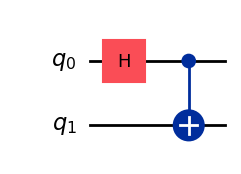

**Bell state**

|00> : 0.7071
|11> : 0.7071
probabilities: {np.str_('00'): np.float64(0.5), np.str_('11'): np.float64(0.5)}


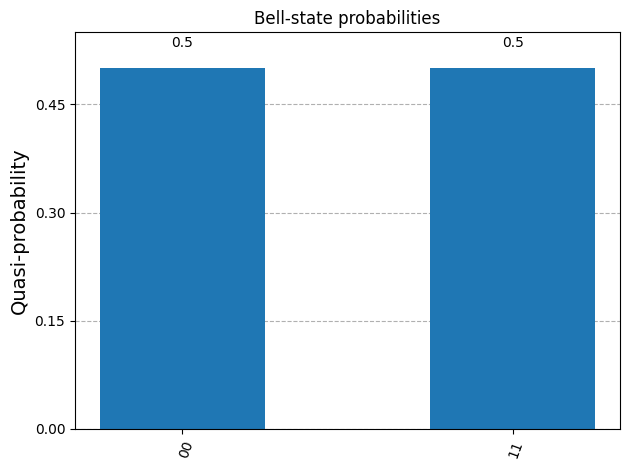

In [16]:
qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)

display_circuit(qc_bell, "Bell-state circuit")
sv_bell = Statevector.from_instruction(qc_bell)
print_statevector(sv_bell, "Bell state")
print("probabilities:", sv_bell.probabilities_dict(decimals=4))
plot_probabilities(sv_bell.probabilities_dict(decimals=4), title="Bell-state probabilities")

**Takeaway:** The Hadamard gate creates superposition. The CNOT gate converts that superposition into entanglement.

## Experiment 9: Measuring entanglement correlations

In the Bell state, each qubit is individually uncertain, but the two outcomes are correlated.

**Task:** sample the Bell state and compare it with two independent fair coins.

Bell-state counts: {np.str_('00'): np.int64(995), np.str_('11'): np.int64(1005)}


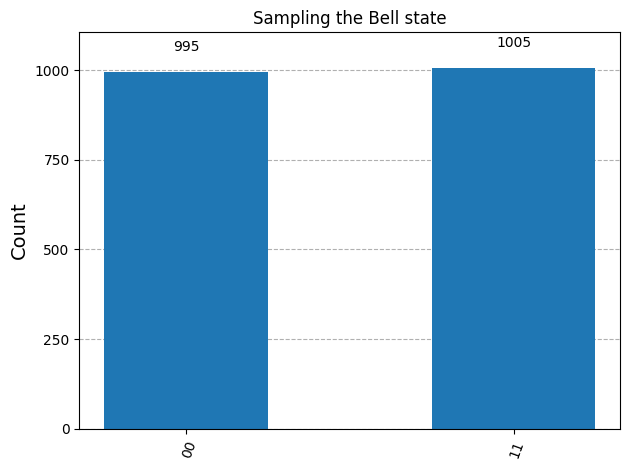

In [17]:
bell_counts = sample_counts(sv_bell, shots=2000)
print("Bell-state counts:", bell_counts)
plot_probabilities(bell_counts, title="Sampling the Bell state")

Product-state counts: {np.str_('00'): np.int64(486), np.str_('01'): np.int64(511), np.str_('10'): np.int64(479), np.str_('11'): np.int64(524)}


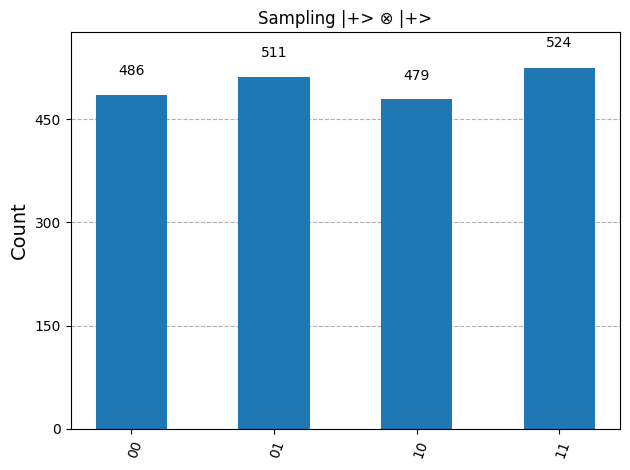

In [18]:
# Two independent fair qubits: |+> ⊗ |+>
qc_product = QuantumCircuit(2)
qc_product.h(0)
qc_product.h(1)

sv_product = Statevector.from_instruction(qc_product)
product_counts = sample_counts(sv_product, shots=2000)

print("Product-state counts:", product_counts)
plot_probabilities(product_counts, title="Sampling |+> ⊗ |+>")

**What to compare:**

- In the product state, all four outcomes should occur.
- In the Bell state, only `00` and `11` should occur in the ideal simulation.
- The Bell-state outcomes are correlated even though each individual qubit is uncertain.

## Experiment 10: Product state vs entangled state

The product state

$$
|+\rangle\otimes|+\rangle = \frac{1}{2}(|00\rangle+|01\rangle+|10\rangle+|11\rangle)
$$

and the Bell state

$$
|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle+|11\rangle)
$$

both involve superposition. Only the Bell state is entangled.

One useful diagnostic is the reduced density matrix. If the total state is pure but a one-qubit reduced state is mixed, the qubits are entangled.

In [19]:
# Reduced state and purity for the product state
rho_product = DensityMatrix(sv_product)
rho_product_q0 = partial_trace(rho_product, [1])  # trace out one qubit

# Reduced state and purity for the Bell state
rho_bell = DensityMatrix(sv_bell)
rho_bell_q0 = partial_trace(rho_bell, [1])

print("Reduced density matrix for one qubit of |+> ⊗ |+>:")
print(np.round(rho_product_q0.data, 4))
print("purity Tr(rho^2):", density_purity(rho_product_q0))
print()

print("Reduced density matrix for one qubit of the Bell state:")
print(np.round(rho_bell_q0.data, 4))
print("purity Tr(rho^2):", density_purity(rho_bell_q0))

Reduced density matrix for one qubit of |+> ⊗ |+>:
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]
purity Tr(rho^2): 0.9999999999999991

Reduced density matrix for one qubit of the Bell state:
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
purity Tr(rho^2): 0.4999999999999998


**Takeaway:** In the product state, the reduced one-qubit state remains pure. In the Bell state, the reduced one-qubit state is mixed, even though the full two-qubit state is pure. This is a signature of entanglement.

## Student exercises

Complete these in the cells below.

1. Create the state

   $$
   \frac{1+i}{2}|0\rangle + \frac{1-i}{2}|1\rangle.
   $$

   Verify whether it is normalized and compute its measurement probabilities.

2. Compute $\langle +|-\rangle$ and $|\langle +|-\rangle|^2$.

3. Construct $|1\rangle \otimes |+\rangle$ manually using `np.kron`. List the nonzero amplitudes.

4. Build a circuit that creates

   $$
   \frac{1}{\sqrt{2}}(|01\rangle + |10\rangle).
   $$

   Verify it using the statevector.

5. Compare sampling results for 50, 500, and 5000 shots for the Bell state.

6. In two or three sentences, explain why observing only `00` and `11` in the Bell state does not mean the system was just two predetermined classical bits.

In [20]:
# Exercise 1
# Create the given complex state, check normalization, and compute probabilities.

# Write your code here.

In [21]:
# Exercise 2
# Compute <+|-> and |<+|->|^2.

# Write your code here.

In [22]:
# Exercise 3
# Construct |1> ⊗ |+> using np.kron and list nonzero amplitudes.

# Write your code here.

In [23]:
# Exercise 4
# Build a circuit for (|01> + |10>)/sqrt(2) and verify it using Statevector.

# Write your code here.

In [24]:
# Exercise 5
# Compare sampling results for 50, 500, and 5000 shots for the Bell state.

# Write your code here.

## Lab record checklist

For each experiment, record:

- the state or circuit prepared,
- the statevector or probability distribution,
- the sampled measurement counts where applicable,
- one sentence explaining the main observation.

## Final takeaways

- Quantum states are complex vectors in Hilbert space.
- Valid states must be normalized.
- Tensor products combine qubits and enlarge the state space.
- Measurement probabilities are squared magnitudes of amplitudes.
- Sampling produces classical outcomes and reveals probabilities statistically.
- Entangled states cannot be described as independent one-qubit states.
- The Bell state is the simplest practical example of entanglement in a two-qubit circuit.